# Phase 3: IC Independence Test via Nested Logistic Regression

This experiment tests whether **LLF (Load Levelling Factor)** and **residualized max(IMB)** provide significant incremental explanatory power beyond **intervener complexity (IC)** in nested logistic regression models predicting real-vs-baseline sentence status.

The pipeline:
1. Loads sentence data (dependency trees) from typologically diverse UD treebanks
2. Generates random projective linearization baselines per sentence
3. Computes IMB profiles, LLF, dependency distance, and IC features
4. Fits 7 nested logistic regression models (A-G) per treebank with likelihood-ratio tests
5. Pools effects via DerSimonian-Laird random-effects meta-analysis
6. Assesses confirmation/disconfirmation criteria

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# statsmodels — NOT pre-installed on Colab
_pip('statsmodels==0.14.6')

# Core packages (pre-installed on Colab, install locally to match Colab env)
# scipy 1.16.3 requires Python >=3.11; use 1.15.3 for Python 3.10 compat
if 'google.colab' not in sys.modules:
    _scipy = 'scipy==1.16.3' if sys.version_info >= (3, 11) else 'scipy==1.15.3'
    _pip('numpy==2.0.2', 'pandas==2.2.2', _scipy, 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import time
import warnings
from collections import defaultdict
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-e4150b-head-directionality-dependent-temporal-d/main/experiment_iter2_phase_3_ic_inde/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['treebanks'])} treebanks:")
for tb_id, tb_data in data["treebanks"].items():
    print(f"  {tb_id}: {len(tb_data['sentences'])} sentences, "
          f"word_order={tb_data['word_order']}, family={tb_data['family']}")

Loaded 3 treebanks:
  en_ewt: 30 sentences, word_order=SVO, family=Indo-European
  ar_padt: 30 sentences, word_order=VSO, family=Afro-Asiatic
  ja_gsd: 30 sentences, word_order=SOV, family=Japonic


## Configuration

All tunable parameters are defined here. Start with minimum values for fast execution.

In [5]:
# --- Tunable parameters ---
# Number of treebanks to process (original: 35, demo data has 3)
N_TREEBANKS = 3

# Max sentences per treebank (original: 400, demo data has 30)
N_SENTENCES = 30

# Baseline linearizations per sentence (original: 50)
N_BASELINES = 30

# Superlinear cost exponents
ALPHAS = [1.0, 1.2, 1.5, 2.0, 3.0]

print(f"Config: {N_TREEBANKS} treebanks, {N_SENTENCES} sentences/tb, {N_BASELINES} baselines/sentence")
print(f"Expected rows per treebank: ~{N_SENTENCES * (1 + N_BASELINES)}")
print(f"Expected total rows: ~{N_TREEBANKS * N_SENTENCES * (1 + N_BASELINES)}")

Config: 3 treebanks, 30 sentences/tb, 30 baselines/sentence
Expected rows per treebank: ~930
Expected total rows: ~2790


## Step 1: Core Computation Functions

IMB (Integration Memory Burden) profile, LLF (Load Levelling Factor), dependency distance features, and intervener complexity features.

In [6]:
def compute_imb_profile(heads: list[int]) -> list[float]:
    """Compute IMB(j) at each position j. heads is 0-indexed list, values are 1-indexed head positions, 0=root."""
    n = len(heads)
    # Build dependency arcs as (open, close) pairs (1-indexed)
    deps = []
    for j in range(n):
        h = heads[j]
        if h != 0:
            dep_pos = j + 1
            deps.append((min(dep_pos, h), max(dep_pos, h)))

    imb = [0.0] * n
    for j_pos in range(1, n + 1):
        burden = 0.0
        for op, cl in deps:
            if op <= j_pos <= cl:
                burden += (j_pos - op)
        imb[j_pos - 1] = burden
    return imb


def compute_llf(imb: list[float]) -> float:
    """Compute Load Levelling Factor from IMB profile."""
    if not imb:
        return 0.0
    max_imb = max(imb)
    mean_imb = sum(imb) / len(imb)
    return mean_imb / max_imb if max_imb > 0 else 0.0


def compute_dd_features(heads: list[int]) -> tuple[float, float, float, list[int]]:
    """Compute dependency distance features from heads array."""
    dd_list = []
    for i, h in enumerate(heads):
        if h != 0:
            dd_list.append(abs((i + 1) - h))
    if not dd_list:
        return 0.0, 0.0, 0.0, dd_list
    arr = np.array(dd_list, dtype=np.float64)
    mean_dd = float(np.mean(arr))
    dd_var = float(np.var(arr))
    if len(dd_list) >= 3 and np.std(arr) > 0:
        dd_skew = float(np.mean(((arr - np.mean(arr)) / np.std(arr)) ** 3))
    else:
        dd_skew = 0.0
    return mean_dd, dd_var, dd_skew, dd_list


def compute_ic_features(heads: list[int]) -> tuple[float, float, int]:
    """Compute intervener complexity features from heads array."""
    n = len(heads)
    head_set = set()
    for h in heads:
        if h != 0:
            head_set.add(h)
    ic_list = []
    for i in range(n):
        h = heads[i]
        if h == 0:
            continue
        pos = i + 1
        a, b = min(pos, h), max(pos, h)
        ic_list.append(sum(1 for k in range(a + 1, b) if k in head_set))
    if not ic_list:
        return 0.0, 0.0, 0
    arr = np.array(ic_list, dtype=np.float64)
    return float(np.mean(arr)), float(np.var(arr)), int(np.max(arr))


def compute_alpha_costs(imb_profile: list[float], alphas: list[float] = ALPHAS) -> dict[float, float]:
    """Compute superlinear costs for various alpha values."""
    return {a: sum(v ** a for v in imb_profile) for a in alphas}


# Quick smoke test
heads_a = [0, 1, 2, 2, 3]
imb_a = compute_imb_profile(heads_a)
assert imb_a == [0, 1, 2, 3, 2], f"IMB mismatch: {imb_a}"
llf_a = compute_llf(imb_a)
print(f"Smoke test: heads={heads_a}, IMB={imb_a}, max_IMB={max(imb_a)}, LLF={llf_a:.4f}")
print("Core computation functions OK")

Smoke test: heads=[0, 1, 2, 2, 3], IMB=[0.0, 1.0, 2.0, 3.0, 2.0], max_IMB=3.0, LLF=0.5333
Core computation functions OK


## Step 2: Tree Operations and Baseline Generation

Build children maps from head arrays, sample random projective linearizations, and convert back to head arrays for baseline comparison.

In [7]:
def build_children_map(heads: list[int]) -> tuple[dict[int, list[int]], int | None]:
    """Build children map from heads. Returns (children_map, root_node)."""
    children: dict[int, list[int]] = defaultdict(list)
    root = None
    for i, h in enumerate(heads):
        node = i + 1
        if h == 0:
            root = node
        else:
            children[h].append(node)
    return dict(children), root


def sample_projective_linearization(children_map: dict, root: int, rng) -> list[int]:
    """Sample one random projective linearization of the dependency tree."""
    def _lin(node: int) -> list[int]:
        kids = children_map.get(node, [])
        if not kids:
            return [node]
        left, right = [], []
        for kid in kids:
            if rng.random() < 0.5:
                left.append(kid)
            else:
                right.append(kid)
        rng.shuffle(left)
        rng.shuffle(right)
        result = []
        for kid in left:
            result.extend(_lin(kid))
        result.append(node)
        for kid in right:
            result.extend(_lin(kid))
        return result
    return _lin(root)


def linearization_to_heads(lin: list[int], original_heads: list[int]) -> list[int]:
    """Convert a linearization to a new heads array."""
    new_pos_of = {orig: new_idx + 1 for new_idx, orig in enumerate(lin)}
    new_heads = []
    for orig_pos in lin:
        orig_head = original_heads[orig_pos - 1]
        if orig_head == 0:
            new_heads.append(0)
        else:
            new_heads.append(new_pos_of[orig_head])
    return new_heads


def validate_tree(heads: list[int]) -> bool:
    """Validate that heads form a valid tree (single root, no cycles)."""
    n = len(heads)
    roots = [i for i, h in enumerate(heads) if h == 0]
    if len(roots) != 1:
        return False
    for i in range(n):
        visited = set()
        cur = i
        while heads[cur] != 0:
            if cur in visited:
                return False
            visited.add(cur)
            cur = heads[cur] - 1
            if cur < 0 or cur >= n:
                return False
    return True


print("Tree operations defined OK")

Tree operations defined OK


## Step 3: Process Sentences — Generate Baselines and Compute Features

For each real sentence, compute its features and generate N random projective linearization baselines with recomputed features. This creates the real-vs-baseline dataset for logistic regression.

In [8]:
def process_one_sentence(sent_data: dict, n_baselines: int, rng_seed: int) -> list[dict]:
    """Process one real sentence: compute real features + N baselines."""
    heads = sent_data["heads"]
    children_map, root = build_children_map(heads)
    if root is None:
        return []

    n = len(heads)
    # Real sentence features
    imb_real = compute_imb_profile(heads)
    llf_real = compute_llf(imb_real)
    max_imb_real = max(imb_real) if imb_real else 0.0
    mean_imb_real = sum(imb_real) / len(imb_real) if imb_real else 0.0
    costs_real = compute_alpha_costs(imb_real)

    rows = []
    # Row for real sentence
    row_real = {
        "is_real": 1,
        "sent_id": sent_data["sent_id"],
        "sentence_length": sent_data["sentence_length"],
        "tree_depth": sent_data["tree_depth"],
        "mean_arity": sent_data["mean_arity"],
        "mean_dd": sent_data["mean_dd"],
        "dd_variance": sent_data["dd_variance"],
        "dd_skewness": sent_data["dd_skewness"],
        "mean_ic": sent_data["mean_ic"],
        "ic_variance": sent_data["ic_variance"],
        "max_ic": sent_data["max_ic"],
        "max_imb": max_imb_real,
        "mean_imb": mean_imb_real,
        "llf": llf_real,
    }
    for a, c in costs_real.items():
        row_real[f"cost_alpha_{str(a).replace('.', '_')}"] = c
    rows.append(row_real)

    # Generate baselines
    rng = np.random.RandomState(rng_seed)
    seen_lins: set[tuple[int, ...]] = set()
    original_order = tuple(range(1, n + 1))

    for _ in range(n_baselines * 3):
        if len(rows) - 1 >= n_baselines:
            break
        lin = sample_projective_linearization(children_map, root, rng)
        lin_key = tuple(lin)
        if lin_key in seen_lins or lin_key == original_order:
            continue
        seen_lins.add(lin_key)

        new_heads = linearization_to_heads(lin, heads)
        mean_dd_b, dd_var_b, dd_skew_b, _ = compute_dd_features(new_heads)
        mean_ic_b, ic_var_b, max_ic_b = compute_ic_features(new_heads)
        imb_b = compute_imb_profile(new_heads)
        llf_b = compute_llf(imb_b)
        max_imb_b = max(imb_b) if imb_b else 0.0
        mean_imb_b = sum(imb_b) / len(imb_b) if imb_b else 0.0
        costs_b = compute_alpha_costs(imb_b)

        row_b = {
            "is_real": 0,
            "sent_id": sent_data["sent_id"],
            "sentence_length": sent_data["sentence_length"],
            "tree_depth": sent_data["tree_depth"],
            "mean_arity": sent_data["mean_arity"],
            "mean_dd": mean_dd_b,
            "dd_variance": dd_var_b,
            "dd_skewness": dd_skew_b,
            "mean_ic": mean_ic_b,
            "ic_variance": ic_var_b,
            "max_ic": max_ic_b,
            "max_imb": max_imb_b,
            "mean_imb": mean_imb_b,
            "llf": llf_b,
        }
        for a, c in costs_b.items():
            row_b[f"cost_alpha_{str(a).replace('.', '_')}"] = c
        rows.append(row_b)

    return rows


# Process all treebanks
t_start = time.time()
all_rows: list[dict] = []
treebank_ids = list(data["treebanks"].keys())[:N_TREEBANKS]

for tb_id in treebank_ids:
    tb_data = data["treebanks"][tb_id]
    sentences = tb_data["sentences"][:N_SENTENCES]
    tb_rows = []
    for i, sent in enumerate(sentences):
        seed = hash((tb_id, i)) & 0xFFFFFFFF
        rows = process_one_sentence(sent, N_BASELINES, rng_seed=seed)
        for row in rows:
            row["treebank_id"] = tb_id
        tb_rows.extend(rows)
    all_rows.extend(tb_rows)
    n_real = sum(1 for r in tb_rows if r["is_real"] == 1)
    print(f"  {tb_id}: {len(tb_rows)} rows ({n_real} real, {len(tb_rows) - n_real} baseline)")

df = pd.DataFrame(all_rows)
print(f"\nTotal: {len(df)} rows, {df['is_real'].sum()} real, "
      f"{len(df) - df['is_real'].sum()} baseline")
print(f"Processing time: {time.time() - t_start:.1f}s")

  en_ewt: 930 rows (30 real, 900 baseline)
  ar_padt: 930 rows (30 real, 900 baseline)


  ja_gsd: 930 rows (30 real, 900 baseline)



Total: 2790 rows, 90 real, 2700 baseline
Processing time: 0.3s


## Step 4: Residualization

Residualize max_imb against dependency distance features via OLS regression. This removes the shared variance with DD, isolating the unique contribution of memory burden.

In [9]:
import statsmodels.api as sm
from scipy.stats import chi2, norm


def residualize_max_imb(df: pd.DataFrame) -> tuple[pd.DataFrame, float, str]:
    """Residualize max_imb against DD features via OLS."""
    predictors = ["mean_dd", "dd_variance", "dd_skewness",
                  "sentence_length", "tree_depth", "mean_arity"]
    X = sm.add_constant(df[predictors].values.astype(float))
    y = df["max_imb"].values.astype(float)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = sm.OLS(y, X).fit()

    df = df.copy()
    df["resid_max_imb"] = model.resid
    r_squared = model.rsquared
    summary_str = f"R2={r_squared:.4f}, adj_R2={model.rsquared_adj:.4f}, F={model.fvalue:.1f}"
    return df, r_squared, summary_str


df, r2, resid_summary = residualize_max_imb(df)
print(f"Residualization: {resid_summary}")
print(f"R2={r2:.4f} (high R2 means max_imb is largely predictable from DD features)")

Residualization: R2=0.9291, adj_R2=0.9289, F=6074.3
R2=0.9291 (high R2 means max_imb is largely predictable from DD features)


## Step 5: Nested Logistic Regression Models (per-treebank)

Fit 7 nested logistic regression models per treebank and compute likelihood-ratio tests to assess whether LLF and residualized max_imb add significant explanatory power beyond IC.

In [10]:
def _safe_float(v: Any) -> float:
    """Convert to float, replacing inf/nan with 0."""
    f = float(v)
    if not math.isfinite(f):
        return 0.0
    return f


def fit_nested_models_for_treebank(tb_df: pd.DataFrame) -> tuple[dict, dict]:
    """Fit 7 nested logistic regression models and run LR tests."""
    y = tb_df["is_real"].values

    # Check for degenerate case
    if y.sum() == 0 or y.sum() == len(y):
        return {}, {}

    base_cols = ["mean_dd", "dd_variance", "dd_skewness",
                 "sentence_length", "tree_depth", "mean_arity"]
    ic_cols = ["mean_ic", "ic_variance", "max_ic"]

    models_spec = {
        "A": base_cols,
        "B": base_cols + ic_cols,
        "C": base_cols + ic_cols + ["llf"],
        "D": base_cols + ic_cols + ["resid_max_imb"],
        "E": base_cols + ic_cols + ["llf", "resid_max_imb"],
        "F": base_cols + ["llf"],
        "G": base_cols + ["llf"] + ic_cols,
    }

    results: dict[str, dict] = {}
    fitted: dict[str, Any] = {}

    for name, cols in models_spec.items():
        try:
            # Standardize features to help convergence
            X_raw = tb_df[cols].values.astype(float)
            means = X_raw.mean(axis=0)
            stds = X_raw.std(axis=0)
            stds[stds == 0] = 1.0
            X_std = (X_raw - means) / stds
            X = sm.add_constant(X_std)

            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model = None
                for method in ["lbfgs", "newton", "bfgs"]:
                    try:
                        model = sm.Logit(y, X).fit(disp=0, maxiter=500, method=method)
                        if model.mle_retvals.get("converged", False):
                            break
                    except Exception:
                        continue
                if model is None:
                    model = sm.Logit(y, X).fit_regularized(alpha=0.01, disp=0, maxiter=500)

            converged = getattr(model, 'mle_retvals', {}).get("converged", True)
            fitted[name] = model
            res = {
                "converged": converged,
                "llf": _safe_float(model.llf),
                "aic": _safe_float(model.aic),
                "bic": _safe_float(model.bic),
                "n_params": len(cols) + 1,
                "pseudo_r2": _safe_float(model.prsquared),
            }
            # Extract key variable coefficients
            param_names = ["const"] + cols
            for pn, coef, se, pval in zip(param_names, model.params, model.bse, model.pvalues):
                if pn in ("llf", "resid_max_imb", "mean_ic"):
                    res[f"coeff_{pn}"] = _safe_float(coef)
                    res[f"se_{pn}"] = _safe_float(se)
                    res[f"pval_{pn}"] = _safe_float(pval)
                    res[f"ci_lower_{pn}"] = _safe_float(coef - 1.96 * se)
                    res[f"ci_upper_{pn}"] = _safe_float(coef + 1.96 * se)
            results[name] = res

        except Exception as e:
            results[name] = {"error": str(e)[:200], "converged": False}

    # Likelihood ratio tests
    comparisons = [("B", "C"), ("B", "D"), ("B", "E"), ("A", "B"), ("F", "G")]
    lr_tests: dict[str, dict] = {}
    for restricted, full in comparisons:
        if restricted in fitted and full in fitted:
            try:
                lr_stat = max(0.0, -2.0 * (fitted[restricted].llf - fitted[full].llf))
                df_diff = results[full]["n_params"] - results[restricted]["n_params"]
                if df_diff <= 0:
                    continue
                p_val = float(chi2.sf(lr_stat, df=df_diff))
                lr_tests[f"{restricted}_vs_{full}"] = {
                    "lr_statistic": _safe_float(lr_stat),
                    "df": df_diff,
                    "p_value": _safe_float(p_val),
                    "delta_aic": _safe_float(results[full]["aic"] - results[restricted]["aic"]),
                    "delta_bic": _safe_float(results[full]["bic"] - results[restricted]["bic"]),
                }
            except Exception:
                pass

    return results, lr_tests


# Fit models per treebank
print("Fitting nested logistic regression models per treebank...")
per_tb_results: dict[str, dict] = {}
for tb_id in treebank_ids:
    tb_df = df[df["treebank_id"] == tb_id]
    if len(tb_df) < 10:
        print(f"  Skipping {tb_id}: only {len(tb_df)} rows")
        continue
    try:
        results, lr_tests = fit_nested_models_for_treebank(tb_df)
        if results:
            per_tb_results[tb_id] = {"models": results, "lr_tests": lr_tests}
            n_conv = sum(1 for r in results.values() if r.get("converged", False))
            bc_p = lr_tests.get("B_vs_C", {}).get("p_value", "N/A")
            bd_p = lr_tests.get("B_vs_D", {}).get("p_value", "N/A")
            print(f"  {tb_id}: {n_conv}/7 converged, B->C p={bc_p}, B->D p={bd_p}")
    except Exception as e:
        print(f"  {tb_id} failed: {e}")

print(f"\nSuccessful treebanks: {len(per_tb_results)}")

Fitting nested logistic regression models per treebank...
  en_ewt: 7/7 converged, B->C p=0.06727097060953764, B->D p=0.034717098886435524
  ar_padt: 7/7 converged, B->C p=0.11055069776878275, B->D p=0.028220932836412718


  ja_gsd: 7/7 converged, B->C p=0.5182584893540658, B->D p=0.319627802684839

Successful treebanks: 3


## Step 6: Meta-Analysis (DerSimonian-Laird)

Pool per-treebank effects using random-effects meta-analysis. Computes heterogeneity statistics (I-squared, Q) and pooled effect estimates.

In [11]:
def meta_analysis_dersimonian_laird(effects: list[float], ses: list[float]) -> dict:
    """Random-effects meta-analysis using DerSimonian-Laird estimator."""
    eff = np.array(effects, dtype=np.float64)
    se_arr = np.array(ses, dtype=np.float64)

    # Filter out zero/tiny SEs
    valid = se_arr > 1e-10
    if valid.sum() < 2:
        return {"pooled_effect": 0.0, "se": 0.0, "ci_lower": 0.0, "ci_upper": 0.0,
                "z": 0.0, "p_value": 1.0, "tau2": 0.0, "I2": 0.0,
                "Q": 0.0, "Q_df": 0, "Q_pvalue": 1.0, "k": int(valid.sum())}
    eff = eff[valid]
    se_arr = se_arr[valid]

    weights_fe = 1.0 / (se_arr ** 2)
    theta_fe = np.sum(weights_fe * eff) / np.sum(weights_fe)

    # Q-statistic
    Q = float(np.sum(weights_fe * (eff - theta_fe) ** 2))
    k = len(eff)
    df_q = k - 1
    p_het = float(chi2.sf(Q, df_q)) if df_q > 0 else 1.0

    # DerSimonian-Laird tau-squared
    C = float(np.sum(weights_fe) - np.sum(weights_fe ** 2) / np.sum(weights_fe))
    tau2 = max(0.0, (Q - df_q) / C) if C > 0 else 0.0

    # Random-effects
    weights_re = 1.0 / (se_arr ** 2 + tau2)
    theta_re = float(np.sum(weights_re * eff) / np.sum(weights_re))
    se_re = float(1.0 / np.sqrt(np.sum(weights_re)))

    I2 = max(0.0, (Q - df_q) / Q) * 100 if Q > 0 else 0.0
    z = theta_re / se_re if se_re > 0 else 0.0
    p_re = float(2.0 * norm.sf(abs(z)))

    return {
        "pooled_effect": _safe_float(theta_re),
        "se": _safe_float(se_re),
        "ci_lower": _safe_float(theta_re - 1.96 * se_re),
        "ci_upper": _safe_float(theta_re + 1.96 * se_re),
        "z": _safe_float(z),
        "p_value": _safe_float(p_re),
        "tau2": _safe_float(tau2),
        "I2": _safe_float(I2),
        "Q": _safe_float(Q),
        "Q_df": df_q,
        "Q_pvalue": _safe_float(p_het),
        "k": k,
    }


def run_meta_analysis(per_tb_results: dict, variable: str, model_name: str) -> dict:
    """Extract per-treebank effects and SEs for a variable and run meta-analysis."""
    effects, ses = [], []
    for tb_id, res in per_tb_results.items():
        models = res.get("models", {})
        m = models.get(model_name, {})
        coeff_key = f"coeff_{variable}"
        se_key = f"se_{variable}"
        if coeff_key in m and se_key in m:
            eff = m[coeff_key]
            se = m[se_key]
            if math.isfinite(eff) and math.isfinite(se) and se > 1e-10:
                effects.append(eff)
                ses.append(se)
    if len(effects) < 2:
        return {"pooled_effect": 0.0, "se": 0.0, "ci_lower": 0.0, "ci_upper": 0.0,
                "z": 0.0, "p_value": 1.0, "tau2": 0.0, "I2": 0.0,
                "Q": 0.0, "Q_df": 0, "Q_pvalue": 1.0, "k": len(effects)}
    return meta_analysis_dersimonian_laird(effects, ses)


# Run meta-analyses
print("Running meta-analysis...")
meta_llf = run_meta_analysis(per_tb_results, "llf", "C")
meta_resid = run_meta_analysis(per_tb_results, "resid_max_imb", "D")
meta_ic_bidir = run_meta_analysis(per_tb_results, "mean_ic", "G")

print(f"Meta LLF:       effect={meta_llf['pooled_effect']:.4f}, p={meta_llf['p_value']:.6f}, I2={meta_llf['I2']:.1f}%")
print(f"Meta resid_imb: effect={meta_resid['pooled_effect']:.4f}, p={meta_resid['p_value']:.6f}, I2={meta_resid['I2']:.1f}%")
print(f"Meta IC bidir:  effect={meta_ic_bidir['pooled_effect']:.4f}, p={meta_ic_bidir['p_value']:.6f}, I2={meta_ic_bidir['I2']:.1f}%")

Running meta-analysis...
Meta LLF:       effect=-0.0594, p=0.793893, I2=65.7%
Meta resid_imb: effect=0.0558, p=0.863998, I2=76.1%
Meta IC bidir:  effect=-3.0789, p=0.000011, I2=0.0%


## Step 7: Disconfirmation Assessment

Evaluate preregistered confirmation/disconfirmation criteria based on per-treebank significance rates and meta-analysis pooled effects.

In [12]:
def assess_disconfirmation(per_tb_results: dict, meta_llf: dict,
                           meta_resid: dict) -> dict:
    """Evaluate preregistered confirmation/disconfirmation criteria."""
    n_tbs = len(per_tb_results)
    if n_tbs == 0:
        return {"status": "error", "reason": "no treebank results"}

    bonferroni_threshold = 0.01 / n_tbs

    n_sig_llf = 0
    n_sig_resid = 0
    n_sig_ic_bidir = 0

    for tb_id, res in per_tb_results.items():
        lr = res.get("lr_tests", {})
        bc = lr.get("B_vs_C", {})
        bd = lr.get("B_vs_D", {})
        fg = lr.get("F_vs_G", {})
        if bc.get("p_value", 1.0) < bonferroni_threshold:
            n_sig_llf += 1
        if bd.get("p_value", 1.0) < bonferroni_threshold:
            n_sig_resid += 1
        if fg.get("p_value", 1.0) < bonferroni_threshold:
            n_sig_ic_bidir += 1

    pct_sig_llf = n_sig_llf / n_tbs
    pct_sig_resid = n_sig_resid / n_tbs
    pct_sig_ic_bidir = n_sig_ic_bidir / n_tbs

    meta_llf_sig = meta_llf.get("p_value", 1.0) < 0.01
    meta_resid_sig = meta_resid.get("p_value", 1.0) < 0.01

    confirmed = (pct_sig_llf >= 0.70 or pct_sig_resid >= 0.70) and meta_llf_sig
    disconfirmed = pct_sig_llf < 0.30 and pct_sig_resid < 0.30

    if confirmed:
        status = "confirmed"
    elif disconfirmed:
        status = "disconfirmed"
    else:
        status = "inconclusive"

    return {
        "status": status,
        "n_treebanks": n_tbs,
        "bonferroni_threshold": bonferroni_threshold,
        "pct_significant_llf_B_vs_C": round(pct_sig_llf, 4),
        "n_significant_llf": n_sig_llf,
        "pct_significant_resid_max_imb_B_vs_D": round(pct_sig_resid, 4),
        "n_significant_resid": n_sig_resid,
        "pct_significant_ic_bidirectional_F_vs_G": round(pct_sig_ic_bidir, 4),
        "n_significant_ic_bidir": n_sig_ic_bidir,
        "meta_llf_significant": meta_llf_sig,
        "meta_llf_p_value": meta_llf.get("p_value", 1.0),
        "meta_resid_significant": meta_resid_sig,
        "meta_resid_p_value": meta_resid.get("p_value", 1.0),
    }


assessment = assess_disconfirmation(per_tb_results, meta_llf, meta_resid)
print(f"Disconfirmation status: {assessment['status']}")
print(f"  LLF significant in {assessment['pct_significant_llf_B_vs_C']*100:.1f}% treebanks ({assessment['n_significant_llf']}/{assessment['n_treebanks']})")
print(f"  resid_max_imb significant in {assessment['pct_significant_resid_max_imb_B_vs_D']*100:.1f}% treebanks ({assessment['n_significant_resid']}/{assessment['n_treebanks']})")
print(f"  IC bidirectional significant in {assessment['pct_significant_ic_bidirectional_F_vs_G']*100:.1f}% treebanks ({assessment['n_significant_ic_bidir']}/{assessment['n_treebanks']})")

Disconfirmation status: disconfirmed
  LLF significant in 0.0% treebanks (0/3)
  resid_max_imb significant in 0.0% treebanks (0/3)
  IC bidirectional significant in 66.7% treebanks (2/3)


## Results Visualization

Summary tables and plots of per-treebank model comparisons, LR test results, and meta-analysis forest plot.

In [13]:
# --- Results Summary Table ---
print("=" * 70)
print("MODEL COMPARISON SUMMARY (pseudo R-squared)")
print("=" * 70)
model_names = ["A", "B", "C", "D", "E", "F", "G"]
model_labels = {
    "A": "DD only", "B": "DD+IC", "C": "DD+IC+LLF",
    "D": "DD+IC+resid", "E": "Full", "F": "DD+LLF", "G": "DD+LLF+IC"
}
print(f"{'Model':<8} {'Description':<15} ", end="")
for tb_id in treebank_ids:
    print(f"{tb_id:<14}", end="")
print()
print("-" * 70)
for mn in model_names:
    print(f"{mn:<8} {model_labels[mn]:<15} ", end="")
    for tb_id in treebank_ids:
        res = per_tb_results.get(tb_id, {}).get("models", {}).get(mn, {})
        pr2 = res.get("pseudo_r2", None)
        if pr2 is not None:
            print(f"{pr2:<14.4f}", end="")
        else:
            print(f"{'N/A':<14}", end="")
    print()

print()
print("=" * 70)
print("LIKELIHOOD RATIO TESTS (p-values)")
print("=" * 70)
tests = ["B_vs_C", "B_vs_D", "B_vs_E", "A_vs_B", "F_vs_G"]
test_labels = {"B_vs_C": "B->C (LLF)", "B_vs_D": "B->D (resid)",
               "B_vs_E": "B->E (both)", "A_vs_B": "A->B (IC)", "F_vs_G": "F->G (IC bidir)"}
print(f"{'Test':<20} ", end="")
for tb_id in treebank_ids:
    print(f"{tb_id:<14}", end="")
print()
print("-" * 70)
for test in tests:
    label = test_labels.get(test, test)
    print(f"{label:<20} ", end="")
    for tb_id in treebank_ids:
        lr = per_tb_results.get(tb_id, {}).get("lr_tests", {}).get(test, {})
        pv = lr.get("p_value", None)
        if pv is not None:
            sig = "***" if pv < 0.001 else "**" if pv < 0.01 else "*" if pv < 0.05 else ""
            print(f"{pv:<10.6f}{sig:<4}", end="")
        else:
            print(f"{'N/A':<14}", end="")
    print()

print()
print("=" * 70)
print("META-ANALYSIS RESULTS")
print("=" * 70)
for name, meta_res in [("LLF (Model C)", meta_llf),
                        ("resid_max_imb (Model D)", meta_resid),
                        ("IC bidirectional (Model G)", meta_ic_bidir)]:
    print(f"\n{name}:")
    print(f"  Pooled effect: {meta_res['pooled_effect']:.4f} (SE={meta_res['se']:.4f})")
    print(f"  95% CI: [{meta_res['ci_lower']:.4f}, {meta_res['ci_upper']:.4f}]")
    print(f"  z={meta_res['z']:.4f}, p={meta_res['p_value']:.6f}")
    print(f"  Heterogeneity: I2={meta_res['I2']:.1f}%, tau2={meta_res['tau2']:.4f}")

print(f"\nOverall status: {assessment['status'].upper()}")

MODEL COMPARISON SUMMARY (pseudo R-squared)
Model    Description     en_ewt        ar_padt       ja_gsd        
----------------------------------------------------------------------
A        DD only         0.1526        0.2658        0.2738        
B        DD+IC           0.2420        0.3547        0.2866        
C        DD+IC+LLF       0.2547        0.3643        0.2881        
D        DD+IC+resid     0.2589        0.3728        0.2903        
E        Full            0.2592        0.3738        0.2909        
F        DD+LLF          0.1584        0.2973        0.2762        
G        DD+LLF+IC       0.2547        0.3643        0.2881        

LIKELIHOOD RATIO TESTS (p-values)
Test                 en_ewt        ar_padt       ja_gsd        
----------------------------------------------------------------------
B->C (LLF)           0.067271      0.110551      0.518258      
B->D (resid)         0.034717  *   0.028221  *   0.319628      
B->E (both)          0.102569      0.079409

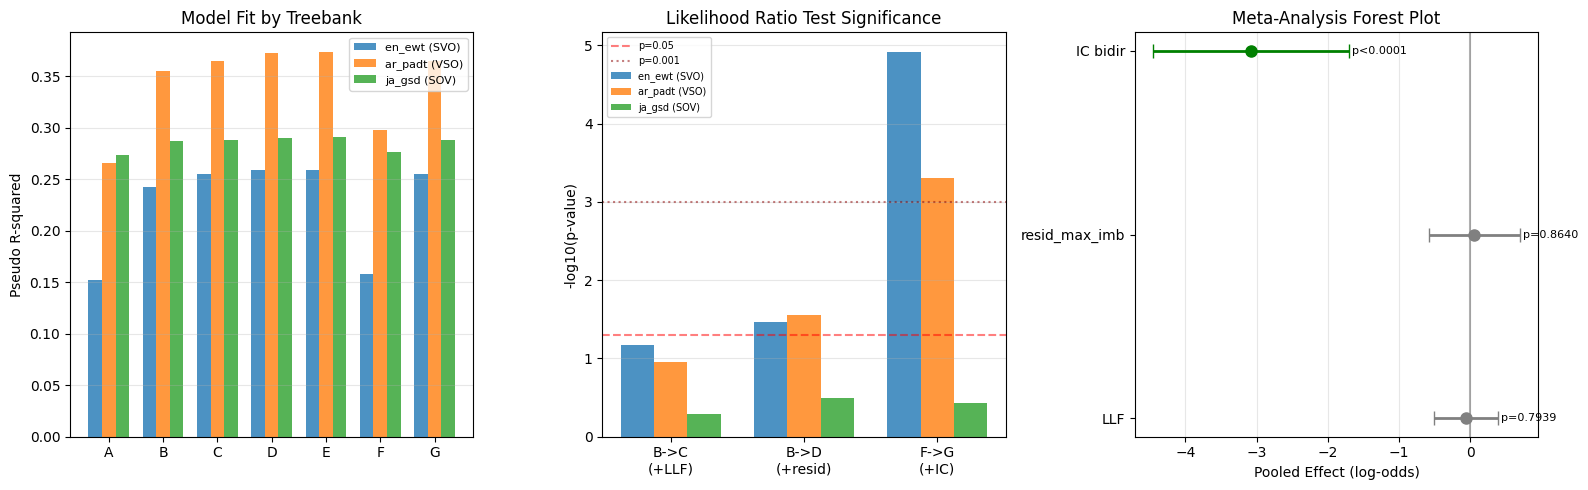

Results plot saved to results_plot.png


In [14]:
# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Pseudo R-squared across models per treebank
ax = axes[0]
x = np.arange(len(model_names))
width = 0.25
for i, tb_id in enumerate(treebank_ids):
    r2_vals = []
    for mn in model_names:
        res = per_tb_results.get(tb_id, {}).get("models", {}).get(mn, {})
        r2_vals.append(res.get("pseudo_r2", 0.0))
    wo = data["treebanks"][tb_id]["word_order"]
    ax.bar(x + i * width, r2_vals, width, label=f"{tb_id} ({wo})", alpha=0.8)
ax.set_xticks(x + width)
ax.set_xticklabels(model_names)
ax.set_ylabel("Pseudo R-squared")
ax.set_title("Model Fit by Treebank")
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Plot 2: LR test p-values (log scale) for key comparisons
ax = axes[1]
key_tests = ["B_vs_C", "B_vs_D", "F_vs_G"]
key_labels = ["B->C\n(+LLF)", "B->D\n(+resid)", "F->G\n(+IC)"]
x = np.arange(len(key_tests))
for i, tb_id in enumerate(treebank_ids):
    pvals = []
    for test in key_tests:
        lr = per_tb_results.get(tb_id, {}).get("lr_tests", {}).get(test, {})
        pv = lr.get("p_value", 1.0)
        pvals.append(max(pv, 1e-50))  # floor for log scale
    wo = data["treebanks"][tb_id]["word_order"]
    ax.bar(x + i * width, [-np.log10(p) for p in pvals], width,
           label=f"{tb_id} ({wo})", alpha=0.8)
ax.axhline(-np.log10(0.05), color='red', linestyle='--', alpha=0.5, label='p=0.05')
ax.axhline(-np.log10(0.001), color='darkred', linestyle=':', alpha=0.5, label='p=0.001')
ax.set_xticks(x + width)
ax.set_xticklabels(key_labels)
ax.set_ylabel("-log10(p-value)")
ax.set_title("Likelihood Ratio Test Significance")
ax.legend(fontsize=7)
ax.grid(axis='y', alpha=0.3)

# Plot 3: Forest plot of meta-analysis effects
ax = axes[2]
meta_vars = [("LLF", meta_llf), ("resid_max_imb", meta_resid), ("IC bidir", meta_ic_bidir)]
y_pos = np.arange(len(meta_vars))
for i, (label, meta_res) in enumerate(meta_vars):
    eff = meta_res["pooled_effect"]
    ci_lo = meta_res["ci_lower"]
    ci_hi = meta_res["ci_upper"]
    color = 'green' if meta_res["p_value"] < 0.05 else 'gray'
    ax.errorbar(eff, i, xerr=[[eff - ci_lo], [ci_hi - eff]],
                fmt='o', color=color, markersize=8, capsize=5, linewidth=2)
    pstr = f"p={meta_res['p_value']:.4f}" if meta_res['p_value'] > 0.0001 else f"p<0.0001"
    ax.annotate(pstr, (ci_hi + 0.05, i), fontsize=8, va='center')
ax.axvline(0, color='black', linestyle='-', alpha=0.3)
ax.set_yticks(y_pos)
ax.set_yticklabels([v[0] for v in meta_vars])
ax.set_xlabel("Pooled Effect (log-odds)")
ax.set_title("Meta-Analysis Forest Plot")
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("results_plot.png", dpi=100, bbox_inches="tight")
plt.show()
print("Results plot saved to results_plot.png")